In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from scipy.stats import f_oneway, chisquare

# Display Basic Information

In [35]:
df = pd.DataFrame(pd.read_csv('/Users/tonmoydutta/Library/CloudStorage/OneDrive-Personal/Study Material/Self Elearning/Scaler/Case Study/Yulu Case Study/bike_sharing.csv'))

display(df.head())

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [36]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [37]:
def explore_data(df):
    print("Data Overview: \n")
    print(df.info())
    print("\n Missing Values: \n", df.isnull().sum())
    print("\n Summary Statistics: \n", df.describe())

df['datetime'] = pd.to_datetime(df['datetime'])

display(explore_data(df))

Data Overview: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB
None

 Missing Values: 
 datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp    

None

Data Overview:
- Dataset contains 10,886 records and 12 columns
- There are no missing values in any column
- The dataset includes numerical and categorical column

# Univariate Analysis

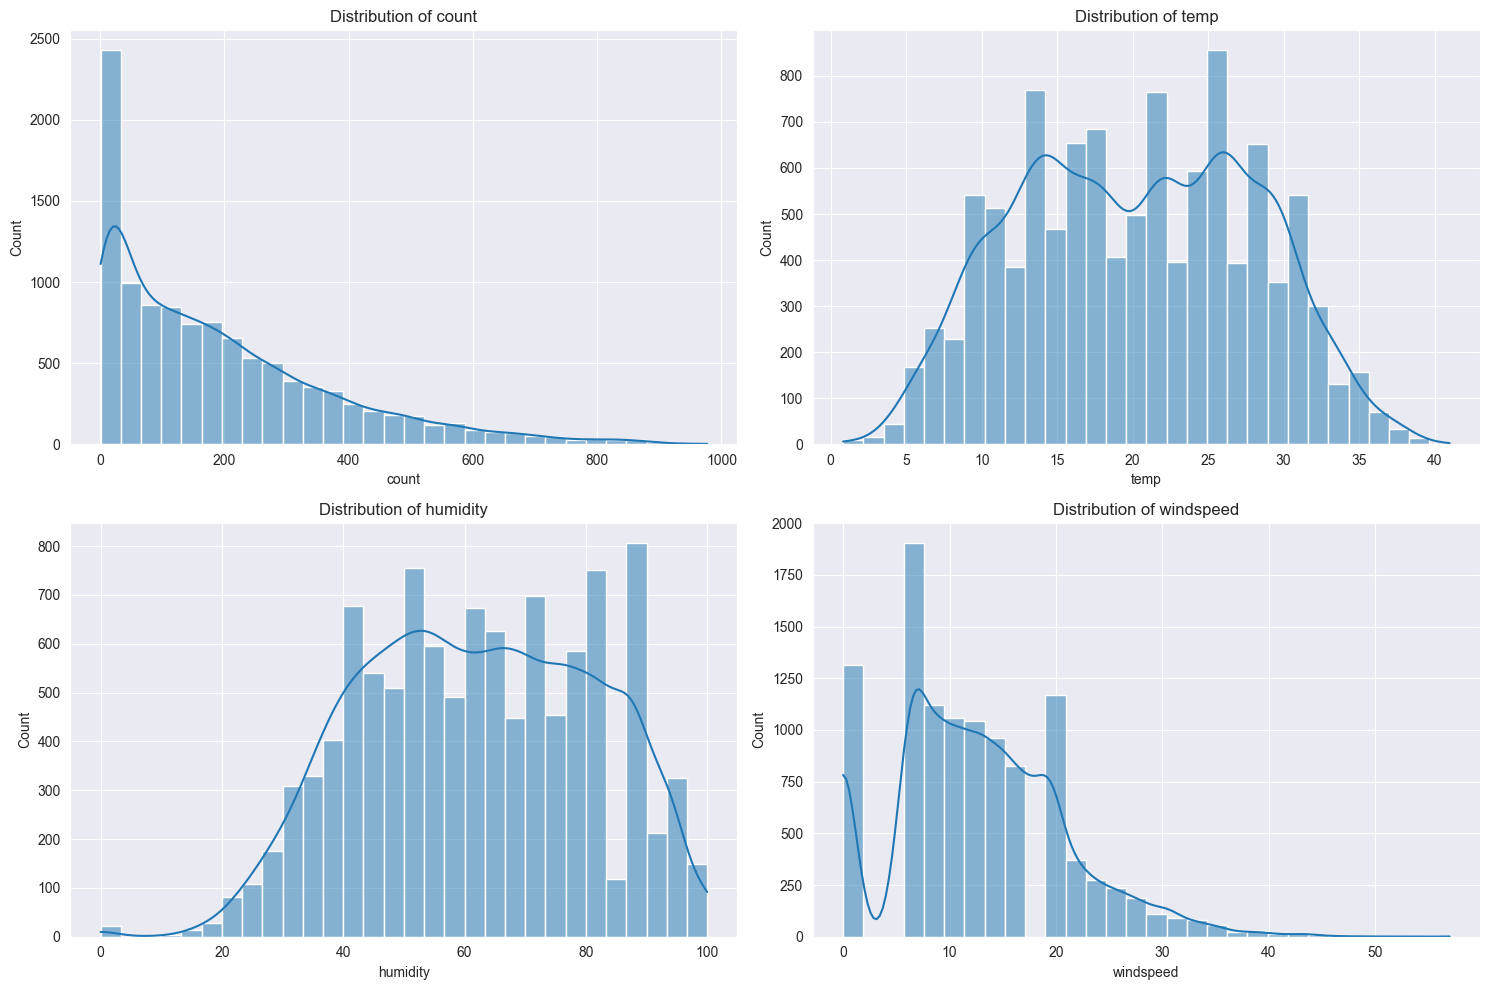

In [38]:
def plot_distribution(df):
    features = ["count","temp", "humidity", "windspeed"]
    plt.figure(figsize = (15,10))
    for i, feature in enumerate(features, 1):
        plt.subplot(2, 2, i)
        sns.histplot(df[feature], bins = 30, kde = True)
        plt.title(f"Distribution of {feature}")
    plt.tight_layout()
    plt.show()

plot_distribution(df)

Univariate Analysis (Distribution Plots) - Observation

1. Bike Count
- The distribution is right-skewed, meaning there are more low rental counts than high counts.
- More rentals fall below 500, with a few instances reaching 977.

2. Temperature
- Normally distributed with a peak around 20-25 degree.
- Very few observation below 5 degree and above 35 degree.

3. Humidity
- Humidity is spread across a wide range (0-100%).
- Peak around 60-80%, indicating humid conditions are common.

4. WindSpeed
- Most values are below 20 km/hr.
- A significant number of values are zero, which may need further investigations.

# Bivariate Analysis

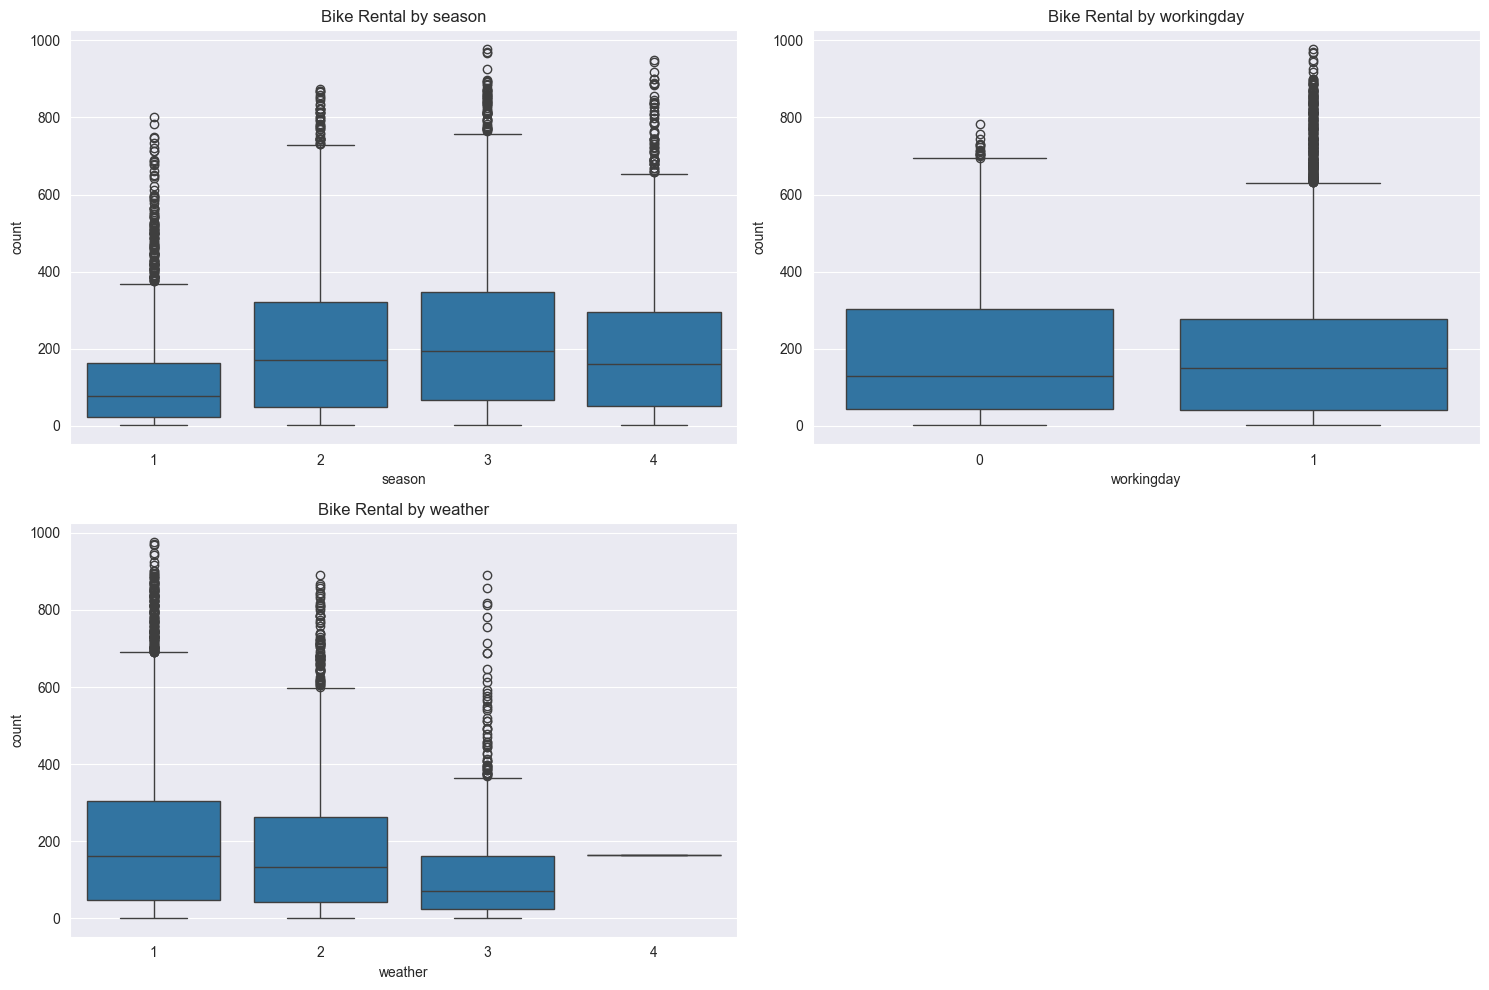

In [39]:
def plot_bivariate(df):
    plt.figure(figsize = (15,10))
    categories = ['season', 'workingday', 'weather']
    for i, category in enumerate(categories, 1):
        plt.subplot(2, 2, i)
        sns.boxplot(x = df[category], y = df['count'])
        plt.title(f"Bike Rental by {category}")
    plt.tight_layout()
    plt.show()

plot_bivariate(df)

Bivariate Analysis - Observations

1. Bike Rentals by season
- Rentals are highest in season 3 and lowest in season 1.
- Season 2 and 4 have moderate rental counts.

2. Bike Rentals by working days
- The median count on working days 1 is slightly higher than the on non-working days 0.
- Thera are more extereme values (i.e. high rentals) on non working days, possibly due to leisure activities.

3. Bike Rentals by weather
- Clear Weather (1) has high rentals
- Misty weather conditions (2) have slighly lower rentals
- Snow and heavy rains (3 & 4) drastically reduce bike rentals

# Hypothesis Testing

In [40]:
# Two Sample t-test: Working days effects on bike rentals

def t_test_working_days(df):
    workingday_rentals = df[df['workingday'] == 1]['count']
    nonworkingday_rentals = df[df['workingday'] == 0]['count']
    t_stat, p_value = stats.ttest_ind(workingday_rentals, nonworkingday_rentals, equal_var = False)
    print("\n Two Sample T_Test Results:")
    print(f"T_Statistic: {t_stat:.4f} , p_value: {p_value:.4f}")
    print("Conclusion:", "Significance Difference" if p_value < 0.05 else "Significance Difference")

t_test_working_days(df)


 Two Sample T_Test Results:
T_Statistic: 1.2363 , p_value: 0.2164
Conclusion: Significance Difference


Null Hypothesis: No significant difference of working days on bike rentals
Alternate Hypothesis: Significant difference of working days on bike rentals

Since the pValue is 0.2164 greater than the significance level of 0.05, we fail to reject null hypothesis

Interpretation: There is no significant difference in bike rentals between working days and non working days

In [55]:
# ANOVA: Season and Weather effects

def anova_test(df):
    anova_season = stats.f_oneway(
        df[df['season'] == 1]['count'],
        df[df['season'] == 2]['count'],
        df[df['season'] == 3]['count'],
        df[df['season'] == 4]['count']
    )
    anova_weather = stats.f_oneway(
        df[df['weather'] == 1]['count'],
        df[df['weather'] == 2]['count'],
        df[df['weather'] == 3]['count'],
        df[df['weather'] == 4]['count']
    )
    print("\n ANOVA Test Results:")
    print(f"Seasonal Effect: F-Statistics: {anova_season.statistic:.4f}, P-Value: {anova_season.pvalue:.10e}")
    print(f"Weather Effect: F-Statistics: {anova_weather.statistic:.4f}, P-Value: {anova_weather.pvalue:.10e}")
    print("Conclusion (Season):", "Significant Difference" if anova_season.pvalue < 0.05 else "No Significant Difference")
    print("Conclusion (Weather)", "Significant Difference" if anova_weather.pvalue < 0.05 else "No Significant Difference")

anova_test(df)


 ANOVA Test Results:
Seasonal Effect: F-Statistics: 236.9467, P-Value: 6.1648433865e-149
Weather Effect: F-Statistics: 65.5302, P-Value: 5.4820694759e-42
Conclusion (Season): Significant Difference
Conclusion (Weather) Significant Difference


ANOVA Test Results

1. The season has a major impact on bike rentals
2. Weather conditions strongly influence the bike rentals

Since both season and weather significantly impact bike rentals. Yulu should consider these factors in their demand forecasting models.

In [56]:
# Chi Square Test: Weather Vs Season

def chi_square_test(df):
    contingency_table = pd.crosstab(df['season'], df['weather'])
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    print('\n Chi-Square Test Results:')
    print(f"Chi-Square Statistics: {chi2_stat:.4f} , p_value: {p_value:.10e}")  # Fixed p-value reference
    print("Conclusion:", "Significant Dependence" if p_value < 0.05 else "No Significant Dependence")

chi_square_test(df)


 Chi-Square Test Results:
Chi-Square Statistics: 49.1587 , p_value: 1.5499250737e-07
Conclusion: Significant Dependence


Interpretation:

Weather condition is significantly dependent on the season.

# Final Insights & Recommendations
1. No significant impact of working days on rentals – Yulu’s bike rentals are consistent across working and non-working days.
2. Season significantly affects demand – Rentals are highest in Fall (3) and lowest in Spring (1).
3. Weather significantly influences rentals – Clear weather has the highest rentals, while snow/rain leads to a drop.
4. Weather conditions depend on the season – Yulu can use this insight to predict demand based on seasonal trends.

# Next Steps for Yulu
1. Adjust pricing and bike availability based on seasonal demand fluctuations.
2. Implement weather-based demand forecasting models.
3. Consider increasing bike availability in Fall and decreasing it in Spring.
4. Optimize marketing efforts based on expected weather conditions.